# AOC 期末專題 ── 第 2 組
# LayerNorm → RMSNorm 替換實驗：ViT-Small/16 on **ImageNet-1k 驗證集**

> **目的**：回應規格書 v3.1 第 6.6 節需求，並以 ImageNet 驗證集（比 CIFAR-10 更嚴格）  
> 驗證「以 RMSNorm 取代 LayerNorm 後，精度損失 < 0.2 pp」  

---

## 資料集說明

| 項目 | 說明 |
|------|------|
| 來源路徑 | `IMAGENET_VAL_HF/` |
| 結構 | 1,000 個子目錄（`00000/` ~ `00999/`），對應 ImageNet 1,000 類 |
| 總張數 | 46,429 張 JPEG（每類 40~50 張）|
| 用途分割 | 評估：全部 46,429 張；微調訓練：80%（~37,143）；微調測試：20%（~9,286）|

## 為何用 ImageNet 驗證？

CIFAR-10 只有 10 類，32×32 低解析度，量化或結構誤差容易被掩蓋。  
ImageNet-1k 有 1,000 類，224×224 高解析度，能更嚴格地驗證 RMSNorm 替換效果。

## 本 Notebook 流程

```
Step 1  繁體中文字型設定 + 安裝依賴 + 全域設定
Step 2  ImageNet 資料集載入（IMAGENET_VAL_HF）+ 視覺化樣本
Step 3  LayerNorm vs RMSNorm 原理視覺化
Step 4  RMSNorm 模組實作
Step 5  模型手術：替換 ViT-Small 中所有 LayerNorm
Step 6  每一層 Norm 結構視覺化
Step 7  前向傳播健康檢查（ImageNet 影像驅動）
Step 8  基準評估：LayerNorm 預訓練模型 @ ImageNet val
Step 9  RMSNorm 零樣本評估（未微調，顯示 β 移除的衝擊）
Step 10 微調訓練（80% val 做訓練集，2 epochs）
Step 11 最終精度對比 + 結論
```

In [1]:
# ═══════════════════════════════════════════════════════════════
# Step 1A：安裝依賴套件
# ═══════════════════════════════════════════════════════════════

import subprocess, sys
for pkg in ["timm>=1.0", "einops"]:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=False)
print("依賴安裝完成")

依賴安裝完成


✅ 繁體中文字型已設定：Microsoft JhengHei


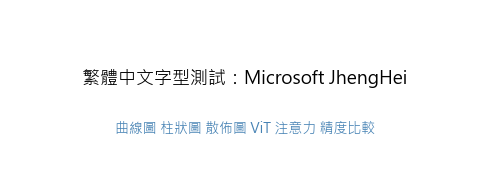

若上方中文正常顯示（非方框），字型設定成功。


In [2]:
# ═══════════════════════════════════════════════════════════════
# Step 1B：繁體中文字型設定
# ═══════════════════════════════════════════════════════════════
#
# Windows 上 Matplotlib 預設使用 DejaVu Sans，不含 CJK 字元，
# 中文會顯示為空格或方框（□□□）。
#
# 解決方式：指定含繁體中文的字型
#   優先順序：
#     1. Microsoft JhengHei（微軟正黑體，Windows 內建）
#     2. Noto Sans TC（Google Noto，需另外安裝）
#     3. DFKai-SB（標楷體，Windows 內建）
#   以上任一字型在系統存在即可正常顯示繁體中文
#
# 需要做的事：
#   (1) 設定 rcParams 的 font.family
#   (2) 清除 Matplotlib 字型快取，讓新設定生效
#   (3) 設定 axes.unicode_minus=False，避免負號顯示為空格

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# ── 自動偵測可用的繁體中文字型 ────────────────────────────────
ZH_FONT_CANDIDATES = [
    "Microsoft JhengHei",   # 微軟正黑體（Windows 繁體版系統字型）
    "Noto Sans TC",         # Google Noto Sans 繁體中文
    "Noto Serif TC",        # Google Noto Serif 繁體中文
    "DFKai-SB",             # 標楷體（Windows 內建）
    "MingLiU",              # 細明體（Windows 內建）
]

def find_available_zh_font(candidates):
    """
    在系統已安裝的字型中，找第一個可用的繁體中文字型。
    fm.fontManager.ttflist 包含所有被 Matplotlib 識別的字型。
    """
    available = {f.name for f in fm.fontManager.ttflist}
    for font_name in candidates:
        if font_name in available:
            return font_name
    return None

ZH_FONT = find_available_zh_font(ZH_FONT_CANDIDATES)

if ZH_FONT:
    # ── 全域套用中文字型 ──
    matplotlib.rcParams['font.family']        = ZH_FONT
    matplotlib.rcParams['axes.unicode_minus'] = False  # 負號不使用 Unicode，避免亂碼
    print(f"✅ 繁體中文字型已設定：{ZH_FONT}")
else:
    print("⚠  找不到繁體中文字型，中文可能顯示為方框")
    print("   請安裝 Microsoft JhengHei 或 Noto Sans TC")

# ── 驗證：畫一個含中文的測試圖 ────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 2))
ax.text(0.5, 0.6, f"繁體中文字型測試：{ZH_FONT}",
        ha='center', va='center', fontsize=13)
ax.text(0.5, 0.3, "曲線圖 柱狀圖 散佈圖 ViT 注意力 精度比較",
        ha='center', va='center', fontsize=10, color='steelblue')
ax.axis('off')
plt.tight_layout()
plt.show()
print("若上方中文正常顯示（非方框），字型設定成功。")

In [3]:
# ═══════════════════════════════════════════════════════════════
# Step 1C：匯入所有函式庫
# ═══════════════════════════════════════════════════════════════

import os, time, copy, warnings, random
import numpy as np
import torch
import torch.nn as nn
import timm
import matplotlib.patches as mpatches
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset, random_split
from collections import OrderedDict

warnings.filterwarnings("ignore")

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

print(f"PyTorch  : {torch.__version__}")
print(f"timm     : {timm.__version__}")
print(f"CUDA 可用 : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU      : {torch.cuda.get_device_name(0)}")

PyTorch  : 2.9.1+cu128
timm     : 1.0.26
CUDA 可用 : True
GPU      : NVIDIA GeForce RTX 5060


In [4]:
# ═══════════════════════════════════════════════════════════════
# Step 1D：全域設定（路徑 + 超參數）
# ═══════════════════════════════════════════════════════════════

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── 路徑設定 ──────────────────────────────────────────────────
# IMAGENET_VAL_DIR：存放 HuggingFace 格式 ImageNet 驗證集
# 結構：IMAGENET_VAL_DIR/00000/*.JPEG  ~ IMAGENET_VAL_DIR/00999/*.JPEG
# 共 1000 個資料夾，每資料夾對應一個 ImageNet 類別
IMAGENET_VAL_DIR = r"C:\Users\User\Desktop\AOC_Final\炸彈惡魔\提報後重新規劃\第二階段\IMAGENET_VAL_HF"
CKPT_DIR         = "./ckpt_rmsnorm_imagenet"    # 本實驗 checkpoint 目錄
os.makedirs(CKPT_DIR, exist_ok=True)

# ── 影像設定 ──────────────────────────────────────────────────
IMG_SIZE      = 224                             # ViT-Small 標準輸入
IMAGENET_MEAN = [0.485, 0.456, 0.406]           # ImageNet 標準化均值
IMAGENET_STD  = [0.229, 0.224, 0.225]           # ImageNet 標準化標準差

# ── 批次設定 ──────────────────────────────────────────────────
BATCH_EVAL    = 128     # 評估用（越大越快，注意 VRAM）
BATCH_TRAIN   = 64      # 微調訓練用

# ── 微調超參數（與規格書 Phase 0 對齊，確保可比較）──────────────
FINETUNE_EPOCHS  = 2    # ImageNet 微調 2 epochs（比 CIFAR-10 少，因為收斂快）
BASE_LR          = 1e-4
LAYER_DECAY      = 0.75
WEIGHT_DECAY     = 0.05
LABEL_SMOOTH     = 0.1

# ── 資料集分割比例 ─────────────────────────────────────────────
TRAIN_RATIO   = 0.8     # 80% 用於微調訓練，20% 用於最終測試

# ── 規格書驗證標準 ──────────────────────────────────────────────
SPEC_THRESHOLD = -0.2   # 規格書 6.6 節：精度損失 < 0.2 pp

print(f"執行裝置   : {DEVICE}")
print(f"ImageNet 路徑：{IMAGENET_VAL_DIR}")
print(f"  存在    : {os.path.isdir(IMAGENET_VAL_DIR)}")
print(f"Checkpoint : {CKPT_DIR}")

執行裝置   : cuda
ImageNet 路徑：C:\Users\User\Desktop\AOC_Final\炸彈惡魔\提報後重新規劃\IMAGENET_VAL_HF
  存在    : True
Checkpoint : ./ckpt_rmsnorm_imagenet


---
## Step 2：ImageNet 資料集載入與視覺化

In [5]:
# ═══════════════════════════════════════════════════════════════
# Step 2A：載入 ImageNet 驗證集（ImageFolder 格式）
# ═══════════════════════════════════════════════════════════════
#
# torchvision.datasets.ImageFolder 自動解析：
#   IMAGENET_VAL_HF/
#     00000/   ← class_idx=0
#       ILSVRC2012_val_XXXXXXXX_n01440764.JPEG
#       ...
#     00001/   ← class_idx=1
#       ...
#
# 因此：資料夾名稱即為 class_name（"00000"~"00999"）
# class_idx = int(class_name)（0~999）
#
# 評估用 transform：標準 ViT 前處理
#   Bicubic resize → CenterCrop → Normalize

assert os.path.isdir(IMAGENET_VAL_DIR), \
    f"ImageNet 路徑不存在：{IMAGENET_VAL_DIR}\n請修改 Step 1D 的 IMAGENET_VAL_DIR"

# ── 評估用 transform（無資料增強，固定輸入）──
transform_eval = transforms.Compose([
    transforms.Resize(256, interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# ── 訓練用 transform（加入資料增強）──
transform_train = transforms.Compose([
    transforms.Resize(256, interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.CenterCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),     # 水平翻轉（防止過擬合）
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),  # 色彩抖動
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# ── 載入完整 val set（用 eval transform，後面再分割）──
inet_full_eval  = datasets.ImageFolder(IMAGENET_VAL_DIR, transform=transform_eval)
inet_full_train = datasets.ImageFolder(IMAGENET_VAL_DIR, transform=transform_train)

N_TOTAL   = len(inet_full_eval)
N_CLASSES = len(inet_full_eval.classes)

print(f"資料集載入完成")
print(f"  總張數   : {N_TOTAL:,}")
print(f"  類別數   : {N_CLASSES}")
print(f"  類別名稱 : {inet_full_eval.classes[:5]} ... {inet_full_eval.classes[-5:]}")
print()

# ── 80/20 分割：train_idx 用於微調，test_idx 用於最終評估 ──
# 使用固定種子確保重現性
# stratified 分割：每類別各取 80% 訓練、20% 測試
train_idx = []
test_idx  = []

# 按類別排列所有 sample 索引
cls_to_indices = {c: [] for c in range(N_CLASSES)}
for idx, (_, label) in enumerate(inet_full_eval.samples):
    cls_to_indices[label].append(idx)

rng = random.Random(SEED)
for cls_idx, indices in cls_to_indices.items():
    shuffled = indices[:]
    rng.shuffle(shuffled)
    n_train = int(len(shuffled) * TRAIN_RATIO)
    train_idx.extend(shuffled[:n_train])
    test_idx.extend(shuffled[n_train:])

print(f"資料分割（各類別 stratified）：")
print(f"  微調訓練用 : {len(train_idx):,} 張（{TRAIN_RATIO*100:.0f}%）")
print(f"  最終測試用 : {len(test_idx):,}  張（{(1-TRAIN_RATIO)*100:.0f}%）")

# ── 建立 DataLoader ──
train_loader = DataLoader(
    Subset(inet_full_train, train_idx),
    batch_size=BATCH_TRAIN, shuffle=True,  num_workers=2, pin_memory=True
)
test_loader = DataLoader(
    Subset(inet_full_eval, test_idx),
    batch_size=BATCH_EVAL,  shuffle=False, num_workers=2, pin_memory=True
)
# 全資料 loader（用於基準評估，不需分割）
full_eval_loader = DataLoader(
    inet_full_eval,
    batch_size=BATCH_EVAL,  shuffle=False, num_workers=2, pin_memory=True
)

print(f"\n微調訓練 batch 數：{len(train_loader)}")
print(f"最終測試 batch 數：{len(test_loader)}")
print(f"全資料評估 batch 數：{len(full_eval_loader)}")

資料集載入完成
  總張數   : 46,429
  類別數   : 1000
  類別名稱 : ['00000', '00001', '00002', '00003', '00004'] ... ['00995', '00996', '00997', '00998', '00999']

資料分割（各類別 stratified）：
  微調訓練用 : 36,720 張（80%）
  最終測試用 : 9,709  張（20%）

微調訓練 batch 數：574
最終測試 batch 數：76
全資料評估 batch 數：363


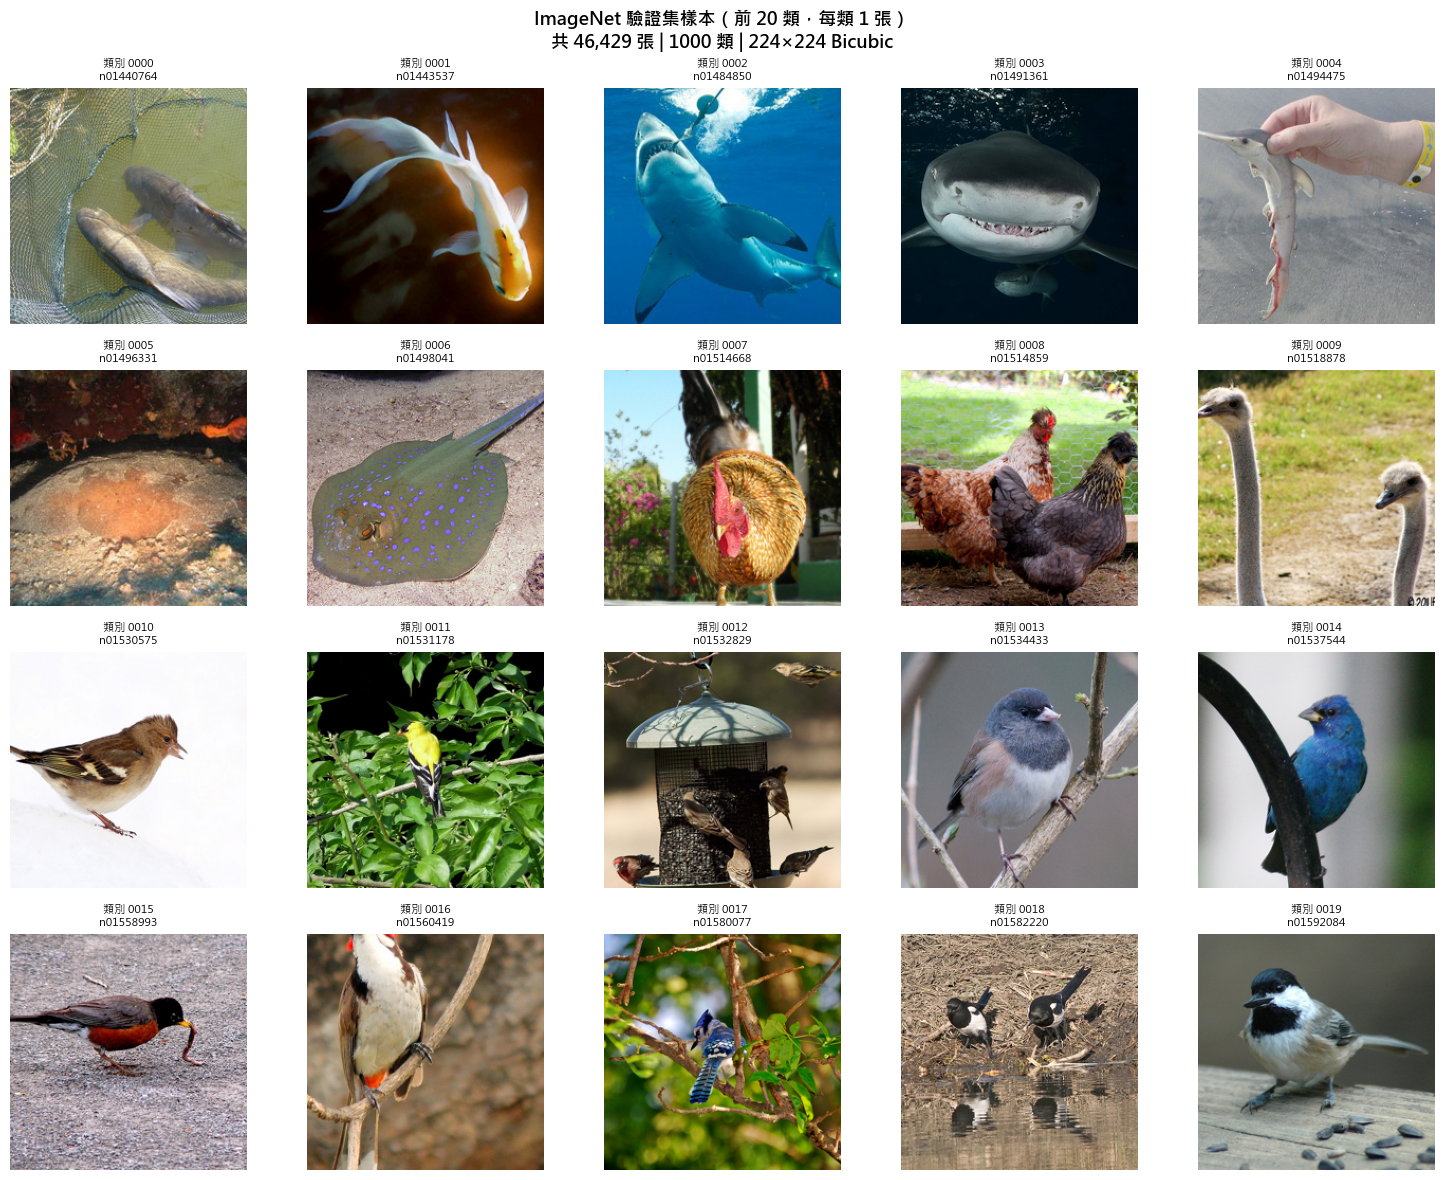

圖片已儲存：imagenet_samples.png


In [6]:
# ═══════════════════════════════════════════════════════════════
# Step 2B：視覺化 ImageNet 樣本（每類各取 1 張）
# ═══════════════════════════════════════════════════════════════
#
# 顯示 20 個類別的代表樣本，確認資料載入正確
# 同時展示 Bicubic 上採樣後的影像品質

# 反標準化函式：把 tensor 還原成可顯示的 [0,1] 影像
def denormalize(tensor):
    """將 ImageNet normalize 過的 tensor 還原到 [0,1] 範圍"""
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1)

# 從前 20 類各取 1 張
n_show    = 20
show_imgs = []
show_cls  = []

# 取得各類別的同義詞（synset）：從檔名中提取
cls_synsets = {}
for path, label in inet_full_eval.samples:
    if label not in cls_synsets:
        fname = os.path.basename(path)     # e.g. ILSVRC2012_val_00000293_n01440764.JPEG
        parts = fname.replace('.JPEG', '').replace('.jpeg', '').split('_')
        synset = parts[-1]                 # e.g. n01440764
        cls_synsets[label] = synset

# 收集前 n_show 類各 1 張（使用 eval transform，直接從 full dataset 取）
seen_cls = set()
for img_tensor, label in inet_full_eval:
    if label not in seen_cls and label < n_show:
        show_imgs.append(img_tensor)
        show_cls.append(label)
        seen_cls.add(label)
    if len(show_imgs) == n_show:
        break

fig, axes = plt.subplots(4, 5, figsize=(15, 12))
axes = axes.flatten()
fig.suptitle("ImageNet 驗證集樣本（前 20 類，每類 1 張）\n"
             f"共 {N_TOTAL:,} 張 | {N_CLASSES} 類 | 224×224 Bicubic",
             fontsize=13, fontweight='bold')

for i, (img_t, cls_idx) in enumerate(zip(show_imgs, show_cls)):
    img_np = denormalize(img_t).permute(1, 2, 0).numpy()
    axes[i].imshow(img_np)
    axes[i].axis('off')
    synset  = cls_synsets.get(cls_idx, '?')
    axes[i].set_title(f"類別 {cls_idx:04d}\n{synset}", fontsize=8)

plt.tight_layout()
plt.savefig("imagenet_samples.png", dpi=100)
plt.show()
print(f"圖片已儲存：imagenet_samples.png")

---
## Step 3：LayerNorm vs RMSNorm 原理視覺化

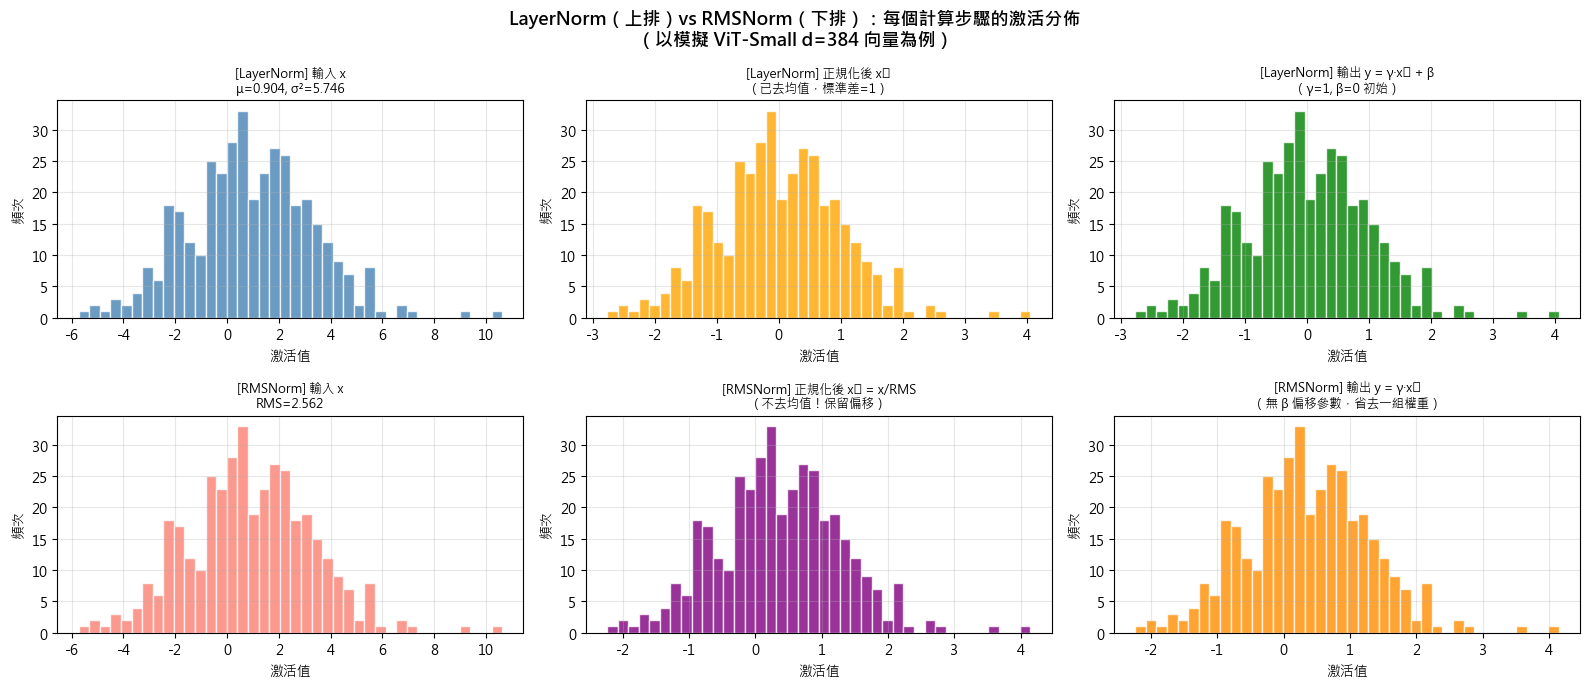

LayerNorm 輸出：均值=-0.0000，標準差=1.0000
RMSNorm  輸出：均值=0.3530，標準差=0.9356

關鍵差異：RMSNorm 不保證輸出均值=0（沒有減去 μ）
         但在 Transformer Pre-Norm 架構中，Residual Connection 可補償此偏移


In [7]:
# ═══════════════════════════════════════════════════════════════
# Step 3：LayerNorm 與 RMSNorm 逐步計算視覺化
# ═══════════════════════════════════════════════════════════════
#
# LayerNorm 公式：y = (x - μ) / sqrt(σ² + ε) * γ + β
#   → 需要 2 次遍歷：先算 μ，再算 σ²
#   → 硬體需要暫存整個向量（d=384 → 768 Bytes for INT16）
#
# RMSNorm 公式：y = x / RMS(x) * γ
#   → 只需 1 次遍歷：直接累加 x²，計算 RMS
#   → FPGA 串流更友好（規格書 6.6 節）

def layernorm_steps(x, gamma, beta, eps=1e-6):
    """LayerNorm 逐步計算，回傳每步中間值"""
    mu    = x.mean()                      # Pass 1：均值
    x_c   = x - mu                        # 中心化
    var   = (x_c ** 2).mean()             # Pass 2：變異數
    x_hat = x_c / (var + eps).sqrt()      # 正規化
    y     = gamma * x_hat + beta          # 仿射
    return y, {"μ": mu.item(), "σ²": var.item(),
               "x_hat": x_hat.numpy(), "y": y.detach().numpy()}

def rmsnorm_steps(x, gamma, eps=1e-6):
    """RMSNorm 逐步計算，回傳每步中間值"""
    rms   = (x ** 2).mean().sqrt()        # Pass 1（唯一一次）：RMS
    x_hat = x / (rms + eps)               # 正規化
    y     = gamma * x_hat                 # 縮放（無 β）
    return y, {"RMS": rms.item(),
               "x_hat": x_hat.numpy(), "y": y.detach().numpy()}

torch.manual_seed(0)
d     = 384
x_t   = torch.randn(d) * 2.5 + 0.8    # 刻意偏移，模擬 Transformer 中間層激活
γ_ln  = torch.ones(d)
β_ln  = torch.zeros(d)
γ_rms = torch.ones(d)

y_ln,  s_ln  = layernorm_steps(x_t, γ_ln,  β_ln)
y_rms, s_rms = rmsnorm_steps(x_t, γ_rms)

fig, axes = plt.subplots(2, 3, figsize=(16, 7))
fig.suptitle("LayerNorm（上排）vs RMSNorm（下排）：每個計算步驟的激活分佈\n"
             "（以模擬 ViT-Small d=384 向量為例）",
             fontsize=13, fontweight='bold')

# 上排：LayerNorm
for ax, data, title, color in zip(
    axes[0],
    [x_t.numpy(), s_ln['x_hat'], s_ln['y']],
    [f"[LayerNorm] 輸入 x\nμ={s_ln['μ']:.3f}, σ²={s_ln['σ²']:.3f}",
     "[LayerNorm] 正規化後 x̂\n（已去均值，標準差=1）",
     "[LayerNorm] 輸出 y = γ·x̂ + β\n（γ=1, β=0 初始）"],
    ['steelblue', 'orange', 'green']
):
    ax.hist(data, bins=40, color=color, alpha=0.8, edgecolor='white')
    ax.set_title(title, fontsize=9)
    ax.set_xlabel("激活值")
    ax.set_ylabel("頻次")
    ax.grid(True, alpha=0.3)

# 下排：RMSNorm
for ax, data, title, color in zip(
    axes[1],
    [x_t.numpy(), s_rms['x_hat'], s_rms['y']],
    [f"[RMSNorm] 輸入 x\nRMS={s_rms['RMS']:.3f}",
     "[RMSNorm] 正規化後 x̂ = x/RMS\n（不去均值！保留偏移）",
     "[RMSNorm] 輸出 y = γ·x̂\n（無 β 偏移參數，省去一組權重）"],
    ['salmon', 'purple', 'darkorange']
):
    ax.hist(data, bins=40, color=color, alpha=0.8, edgecolor='white')
    ax.set_title(title, fontsize=9)
    ax.set_xlabel("激活值")
    ax.set_ylabel("頻次")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("layernorm_vs_rmsnorm_分佈比較.png", dpi=120)
plt.show()

print(f"LayerNorm 輸出：均值={s_ln['y'].mean():.4f}，標準差={s_ln['y'].std():.4f}")
print(f"RMSNorm  輸出：均值={s_rms['y'].mean():.4f}，標準差={s_rms['y'].std():.4f}")
print()
print("關鍵差異：RMSNorm 不保證輸出均值=0（沒有減去 μ）")
print("         但在 Transformer Pre-Norm 架構中，Residual Connection 可補償此偏移")

---
## Step 4：RMSNorm 模組實作

In [8]:
# ═══════════════════════════════════════════════════════════════
# Step 4：RMSNorm PyTorch 模組
# ═══════════════════════════════════════════════════════════════
#
# 與 nn.LayerNorm 接口完全相容，可直接 swap。
#
# FPGA 硬體對應（規格書 6.6 節）：
#   Pass 1（串流 384 個 cycle）：rms_acc += x[i]²
#   rms_sq  = rms_acc >> 9                  （近似除以 384）
#   inv_rms = lut_inv_sqrt[rms_sq >> shift] （1-cycle LUT 查表）
#   Pass 2（串流 384 個 cycle）：y[i] = x[i] * inv_rms * γ[i]
#
# 對比 LayerNorm：需額外一次 Pass 計算 μ，並暫存 384×2B=768B

class RMSNorm(nn.Module):
    """
    Root Mean Square Layer Normalization
    論文：Zhang & Sennrich (2019)  arXiv:1910.07467

    設計要點：
      · 與 nn.LayerNorm 相同接口（drop-in replacement）
      · 無 bias（β）→ 省參數，FPGA 不需存 β 陣列
      · 計算用 FP32，輸出轉回原型別（支援 FP16/BF16 混合精度）
    """

    def __init__(self, normalized_shape, eps=1e-6, elementwise_affine=True):
        super().__init__()
        self.normalized_shape  = (normalized_shape,) if isinstance(normalized_shape, int) \
                                  else tuple(normalized_shape)
        self.eps               = eps
        self.elementwise_affine = elementwise_affine
        # γ 初始化為全 1（等同 identity，與 LayerNorm 初始狀態相同）
        self.weight = nn.Parameter(torch.ones(self.normalized_shape)) \
                      if elementwise_affine else None
        self.bias   = None  # RMSNorm 無 β，宣告 None 以相容屬性存取

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x shape: (..., d)  ← 最後一維為 d_model（ViT-Small: 384）
        計算：
          ① x_sq_mean = mean(x², dim=-1, keepdim=True)  ← FPGA Pass 1
          ② inv_rms   = rsqrt(x_sq_mean + eps)          ← FPGA LUT
          ③ y = x * inv_rms * γ                         ← FPGA Pass 2
        """
        orig_dtype = x.dtype
        x_f = x.float()                                       # 用 FP32 計算防溢位
        rms_sq  = x_f.pow(2).mean(dim=-1, keepdim=True)      # ①
        inv_rms = torch.rsqrt(rms_sq + self.eps)              # ②
        y       = x_f * inv_rms                               # ③（前半）
        if self.weight is not None:
            y = y * self.weight.float()                       # ③（γ 縮放）
        return y.to(orig_dtype)

    def extra_repr(self):
        return (f"normalized_shape={self.normalized_shape}, "
                f"eps={self.eps}, elementwise_affine={self.elementwise_affine}")


# ── 單元測試 ───────────────────────────────────────────────────
print("RMSNorm 單元測試（ViT-Small 真實維度）")
x_chk = torch.randn(4, 197, 384)          # batch=4, tokens=197, d=384
rms   = RMSNorm(384)
y_chk = rms(x_chk)
print(f"  輸入  shape: {x_chk.shape}")
print(f"  輸出  shape: {y_chk.shape}  ← 應與輸入相同")
print(f"  輸出均值: {y_chk.mean():.4f}  標準差: {y_chk.std():.4f}")
print(f"  接口測試 ✅")

RMSNorm 單元測試（ViT-Small 真實維度）
  輸入  shape: torch.Size([4, 197, 384])
  輸出  shape: torch.Size([4, 197, 384])  ← 應與輸入相同
  輸出均值: -0.0038  標準差: 1.0000
  接口測試 ✅


---
## Step 5：模型手術——替換 ViT-Small 中所有 LayerNorm

In [9]:
# ═══════════════════════════════════════════════════════════════
# Step 5A：工具函式
# ═══════════════════════════════════════════════════════════════

def find_norm_layers(model, norm_type):
    """遞迴找出模型中所有指定型別的 Norm 層，回傳 (name, parent, attr, module) 列表"""
    found = []
    for name, module in model.named_modules():
        if isinstance(module, norm_type):
            parts  = name.split('.')
            parent = model
            for p in parts[:-1]:
                parent = getattr(parent, p)
            found.append({'full_name': name, 'attr_name': parts[-1],
                          'parent': parent, 'module': module})
    return found


def replace_layernorm_with_rmsnorm(model, copy_weights=True):
    """
    將模型中所有 nn.LayerNorm 替換為 RMSNorm

    copy_weights=True：
      將 LayerNorm 的 γ（weight）複製到 RMSNorm
      → 替換後初始輸出接近原始值，減少微調所需步驟
      β（bias）會被捨棄（RMSNorm 無 β）
    """
    ln_list    = find_norm_layers(model, nn.LayerNorm)
    n_replaced = 0
    for info in ln_list:
        ln = info['module']
        new_rms = RMSNorm(ln.normalized_shape, eps=ln.eps,
                          elementwise_affine=(ln.weight is not None))
        if copy_weights and ln.weight is not None:
            with torch.no_grad():
                new_rms.weight.copy_(ln.weight)  # 複製 γ，丟棄 β
        setattr(info['parent'], info['attr_name'], new_rms)
        n_replaced += 1
    return n_replaced


@torch.no_grad()
def evaluate(model, loader, device=DEVICE, max_batches=None, desc="評估"):
    """Top-1 準確率評估"""
    model.eval()
    model.to(device)
    correct = total = 0
    for i, (imgs, labels) in enumerate(loader):
        if max_batches and i >= max_batches:
            break
        imgs, labels = imgs.to(device), labels.to(device)
        preds = model(imgs).argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)
        if (i + 1) % 50 == 0:
            print(f"  [{desc}] {i+1}/{len(loader) if max_batches is None else max_batches} "
                  f"已處理 {total:,} 張 | 當前準確率 {100*correct/total:.2f}%")
    return 100.0 * correct / total


print("工具函式定義完成")

工具函式定義完成


In [10]:
# ═══════════════════════════════════════════════════════════════
# Step 5B：載入 ViT-Small 預訓練模型（1000 類，ImageNet 預訓練）
# ═══════════════════════════════════════════════════════════════
#
# 注意：這裡使用 num_classes=1000（ImageNet 原始），不是 CIFAR-10 的 10
# 因為我們要在 ImageNet val set 評估

print("載入 ViT-Small 預訓練模型（ImageNet-21k → ImageNet-1k）...")
model_ln = timm.create_model(
    'vit_small_patch16_224.augreg_in21k_ft_in1k',
    pretrained=True,
    num_classes=1000   # ImageNet 1000 類
)
model_ln.eval()

total_params = sum(p.numel() for p in model_ln.parameters())
print(f"\nViT-Small (LayerNorm) 載入完成")
print(f"  總參數量 : {total_params/1e6:.2f} M")
print(f"  LayerNorm 層數 : {len(find_norm_layers(model_ln, nn.LayerNorm))}")

# ── 建立 RMSNorm 版本（deepcopy 後替換）──
model_rms = copy.deepcopy(model_ln)
n = replace_layernorm_with_rmsnorm(model_rms, copy_weights=True)

params_rms = sum(p.numel() for p in model_rms.parameters())
print(f"\nViT-Small (RMSNorm) 建立完成")
print(f"  替換層數 : {n}")
print(f"  總參數量 : {params_rms/1e6:.2f} M（節省 {(total_params-params_rms)/1e3:.1f}K β 參數）")
print(f"  LayerNorm 層數 : {len(find_norm_layers(model_rms, nn.LayerNorm))}  ← 應為 0")
print(f"  RMSNorm  層數 : {len(find_norm_layers(model_rms, RMSNorm))}  ← 應為 {n}")

載入 ViT-Small 預訓練模型（ImageNet-21k → ImageNet-1k）...



ViT-Small (LayerNorm) 載入完成
  總參數量 : 22.05 M
  LayerNorm 層數 : 25

ViT-Small (RMSNorm) 建立完成
  替換層數 : 25
  總參數量 : 22.04 M（節省 9.6K β 參數）
  LayerNorm 層數 : 0  ← 應為 0
  RMSNorm  層數 : 25  ← 應為 25


---
## Step 6：每一層 Norm 結構視覺化

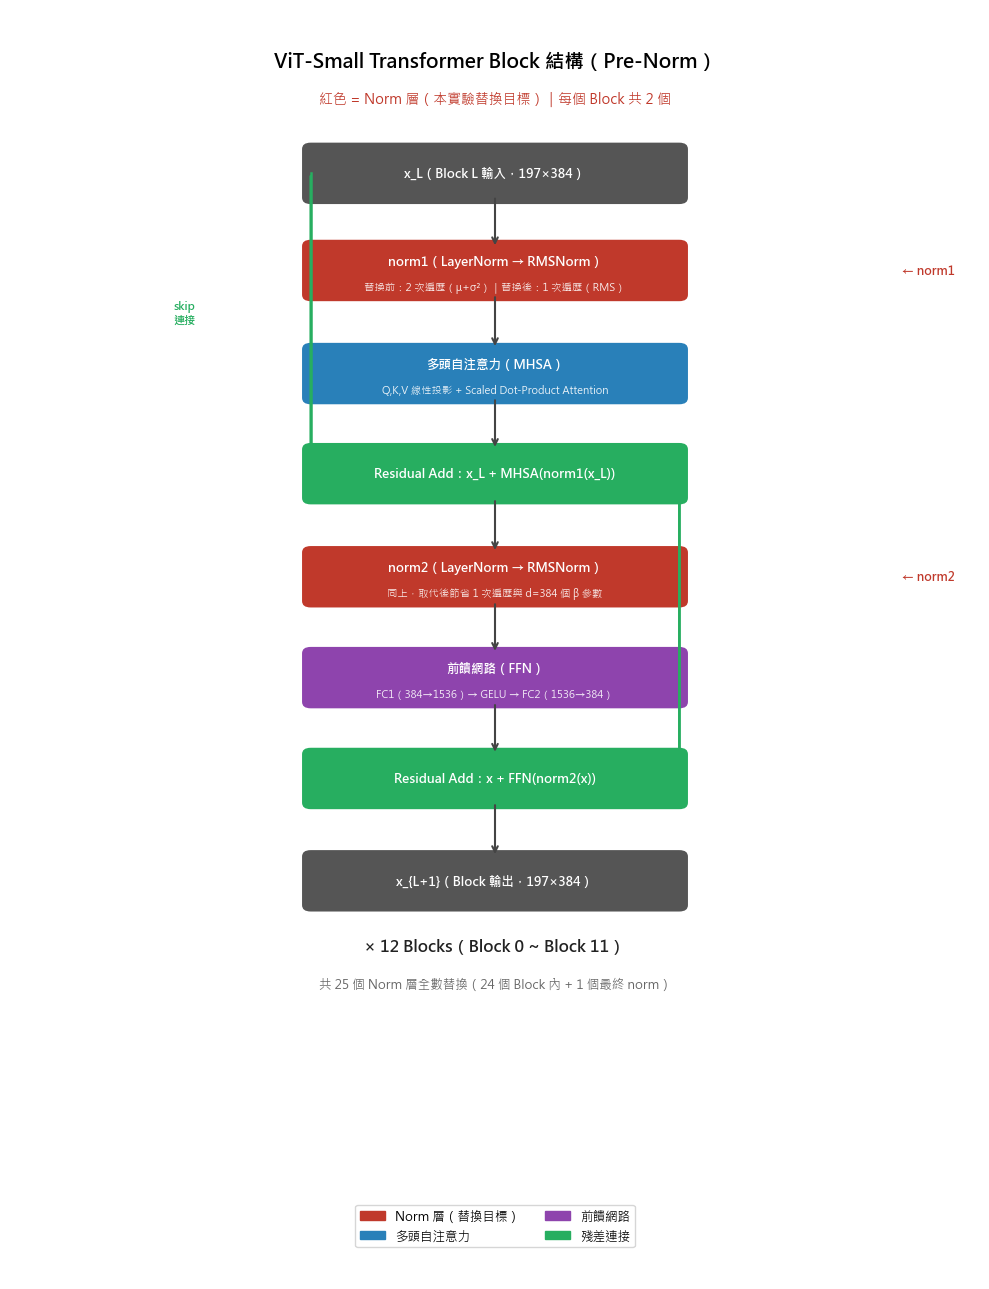

In [11]:
# ═══════════════════════════════════════════════════════════════
# Step 6A：ViT Block 結構圖（顯示 norm1/norm2 位置）
# ═══════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(10, 13))
ax.set_xlim(0, 10); ax.set_ylim(0, 17)
ax.axis('off')

def box(ax, x, y, w, h, label, sub='', fc='#4a90d9', tc='white', fs=9):
    r = mpatches.FancyBboxPatch((x-w/2, y-h/2), w, h,
                                boxstyle='round,pad=0.1', facecolor=fc,
                                edgecolor='white', linewidth=1.5)
    ax.add_patch(r)
    ax.text(x, y + (0.12 if sub else 0), label, ha='center', va='center',
            fontsize=fs, fontweight='bold', color=tc)
    if sub:
        ax.text(x, y - 0.22, sub, ha='center', va='center', fontsize=7.5, color=tc, alpha=0.9)

def arr(ax, x1, y1, x2, y2):
    ax.annotate('', xy=(x2,y2), xytext=(x1,y1),
                arrowprops=dict(arrowstyle='->', color='#444', lw=1.5))

ax.text(5, 16.3, 'ViT-Small Transformer Block 結構（Pre-Norm）',
        ha='center', va='center', fontsize=14, fontweight='bold')
ax.text(5, 15.8, '紅色 = Norm 層（本實驗替換目標）｜每個 Block 共 2 個',
        ha='center', va='center', fontsize=10, color='#c0392b')

box(ax, 5, 14.8, 3.8, 0.65, 'x_L（Block L 輸入，197×384）',
    fc='#555', fs=9)
arr(ax, 5, 14.5, 5, 13.8)
box(ax, 5, 13.5, 3.8, 0.65, 'norm1（LayerNorm → RMSNorm）',
    sub='替換前：2 次遍歷（μ+σ²）｜替換後：1 次遍歷（RMS）',
    fc='#c0392b', fs=9)
ax.text(9.2, 13.5, '← norm1', va='center', fontsize=8.5, color='#c0392b', fontweight='bold')
arr(ax, 5, 13.18, 5, 12.45)
box(ax, 5, 12.12, 3.8, 0.65, '多頭自注意力（MHSA）',
    sub='Q,K,V 線性投影 + Scaled Dot-Product Attention',
    fc='#2980b9', fs=9)

# 殘差 1
arr(ax, 5, 11.8, 5, 11.1)
box(ax, 5, 10.78, 3.8, 0.65, 'Residual Add：x_L + MHSA(norm1(x_L))',
    fc='#27ae60', fs=9)
ax.plot([3.1, 3.1], [14.8, 10.78], color='#27ae60', lw=1.8)
ax.annotate('', xy=(3.1, 10.78), xytext=(3.1, 14.8),
            arrowprops=dict(arrowstyle='->', color='#27ae60', lw=1.8))
ax.plot([3.1, 5-1.9], [14.8, 14.8], color='#27ae60', lw=1.8)
ax.plot([3.1, 5-1.9], [10.78, 10.78], color='#27ae60', lw=1.8)
ax.text(1.8, 12.8, 'skip\n連接', ha='center', fontsize=8, color='#27ae60', fontweight='bold')

arr(ax, 5, 10.45, 5, 9.72)
box(ax, 5, 9.4, 3.8, 0.65, 'norm2（LayerNorm → RMSNorm）',
    sub='同上，取代後節省 1 次遍歷與 d=384 個 β 參數',
    fc='#c0392b', fs=9)
ax.text(9.2, 9.4, '← norm2', va='center', fontsize=8.5, color='#c0392b', fontweight='bold')
arr(ax, 5, 9.07, 5, 8.37)
box(ax, 5, 8.05, 3.8, 0.65, '前饋網路（FFN）',
    sub='FC1（384→1536）→ GELU → FC2（1536→384）',
    fc='#8e44ad', fs=9)

# 殘差 2
arr(ax, 5, 7.72, 5, 7.02)
box(ax, 5, 6.7, 3.8, 0.65, 'Residual Add：x + FFN(norm2(x))',
    fc='#27ae60', fs=9)
ax.plot([6.9, 6.9], [10.78, 6.7], color='#27ae60', lw=1.8)
ax.annotate('', xy=(6.9, 6.7), xytext=(6.9, 10.78),
            arrowprops=dict(arrowstyle='->', color='#27ae60', lw=1.8))
ax.plot([6.9, 5+1.9], [10.78, 10.78], color='#27ae60', lw=1.8)
ax.plot([6.9, 5+1.9], [6.7, 6.7],   color='#27ae60', lw=1.8)

arr(ax, 5, 6.38, 5, 5.65)
box(ax, 5, 5.33, 3.8, 0.65, 'x_{L+1}（Block 輸出，197×384）',
    fc='#555', fs=9)

ax.text(5, 4.4, '× 12 Blocks（Block 0 ~ Block 11）',
        ha='center', fontsize=11.5, color='#222', fontweight='bold')
ax.text(5, 3.9, f'共 {n} 個 Norm 層全數替換（24 個 Block 內 + 1 個最終 norm）',
        ha='center', fontsize=9, color='#666')

# 圖例
legend_items = [
    mpatches.Patch(color='#c0392b', label='Norm 層（替換目標）'),
    mpatches.Patch(color='#2980b9', label='多頭自注意力'),
    mpatches.Patch(color='#8e44ad', label='前饋網路'),
    mpatches.Patch(color='#27ae60', label='殘差連接'),
]
ax.legend(handles=legend_items, loc='lower center',
          bbox_to_anchor=(0.5, 0.02), ncol=2, fontsize=9)

plt.tight_layout()
plt.savefig("ViT_Block結構_Norm層位置.png", dpi=120, bbox_inches='tight')
plt.show()

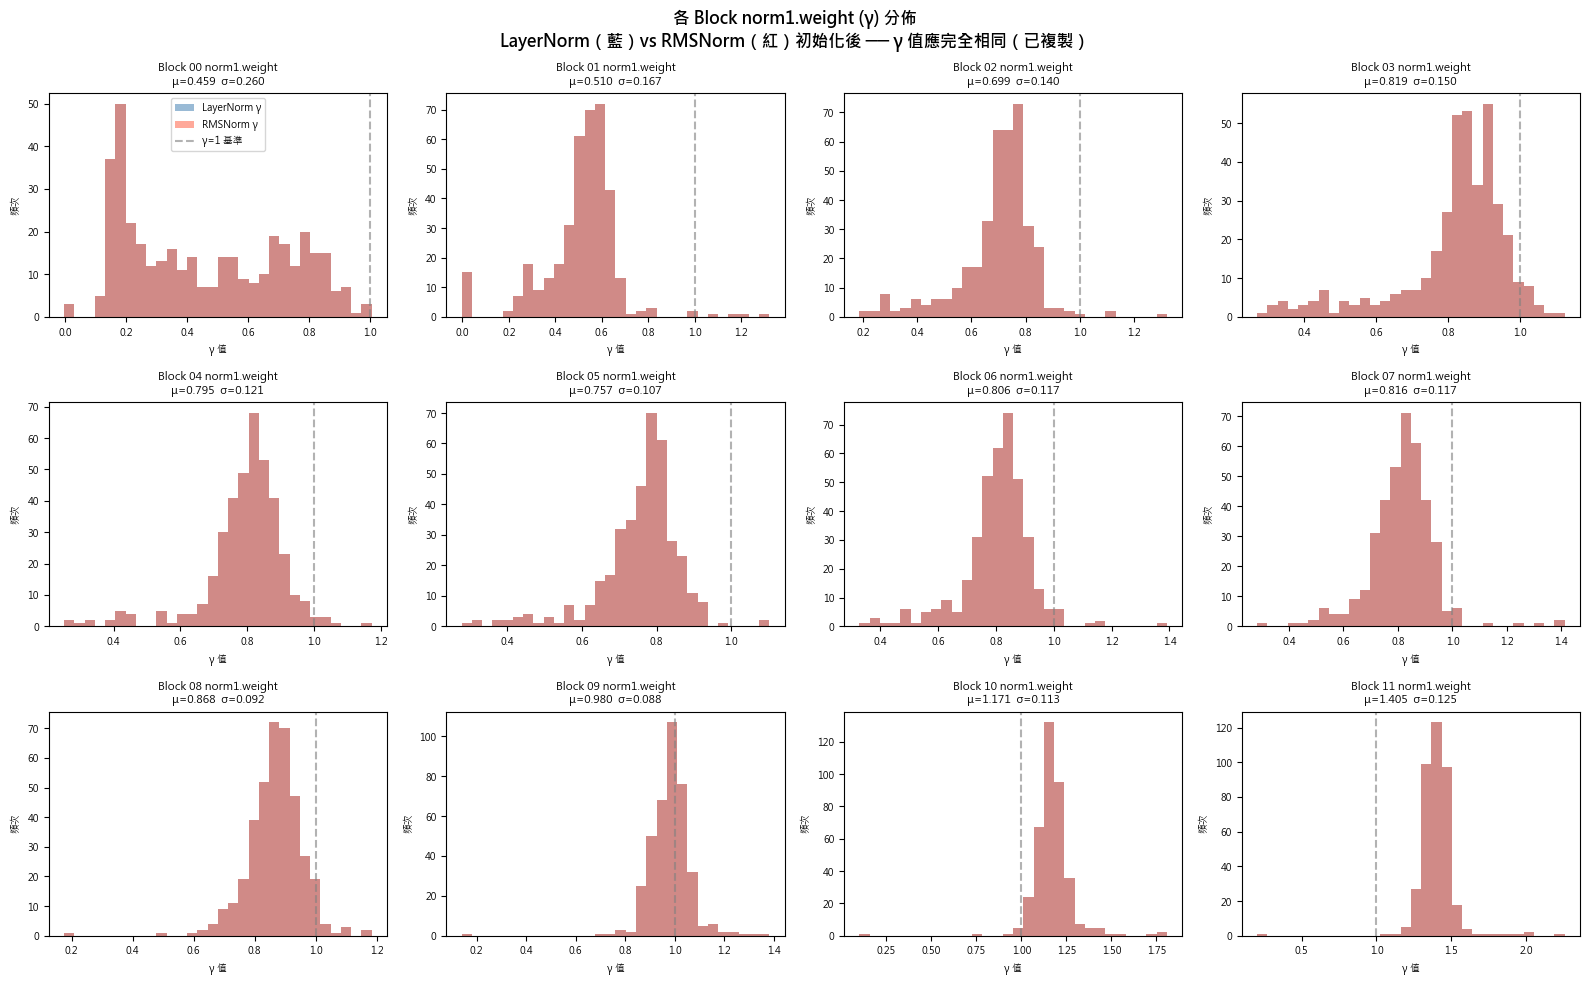

說明：γ 均值偏離 1.0 代表預訓練時縮放調整幅度
     LayerNorm 和 RMSNorm 的 γ 完全相同（直接複製），初始輸出接近原始值


In [12]:
# ═══════════════════════════════════════════════════════════════
# Step 6B：各 Block γ 權重分佈視覺化
# ═══════════════════════════════════════════════════════════════
#
# 顯示預訓練 LayerNorm γ 的分佈（複製到 RMSNorm 後應完全相同）
# γ 偏離 1.0 越多，代表這一層的縮放調整越大

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()
fig.suptitle("各 Block norm1.weight (γ) 分佈\n"
             "LayerNorm（藍）vs RMSNorm（紅）初始化後 ── γ 值應完全相同（已複製）",
             fontsize=12, fontweight='bold')

for idx in range(12):
    ax = axes[idx]
    γ_ln  = model_ln.blocks[idx].norm1.weight.detach().numpy()
    γ_rms = model_rms.blocks[idx].norm1.weight.detach().numpy()

    ax.hist(γ_ln,  bins=30, alpha=0.55, color='steelblue', label='LayerNorm γ')
    ax.hist(γ_rms, bins=30, alpha=0.55, color='tomato',    label='RMSNorm γ')
    ax.axvline(1.0, color='gray', linestyle='--', alpha=0.6, label='γ=1 基準')

    ax.set_title(f"Block {idx:02d} norm1.weight\n"
                 f"μ={γ_ln.mean():.3f}  σ={γ_ln.std():.3f}", fontsize=8)
    ax.set_xlabel('γ 值', fontsize=7)
    ax.set_ylabel('頻次', fontsize=7)
    ax.tick_params(labelsize=7)
    if idx == 0:
        ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig("各Block_gamma分佈.png", dpi=120)
plt.show()
print("說明：γ 均值偏離 1.0 代表預訓練時縮放調整幅度")
print("     LayerNorm 和 RMSNorm 的 γ 完全相同（直接複製），初始輸出接近原始值")

---
## Step 7：前向傳播健康檢查（ImageNet 影像驅動）

執行健康檢查（使用 ImageNet 真實影像）...
[LayerNorm 預訓練] 記錄 37 層
[RMSNorm  （未微調）] 記錄 37 層


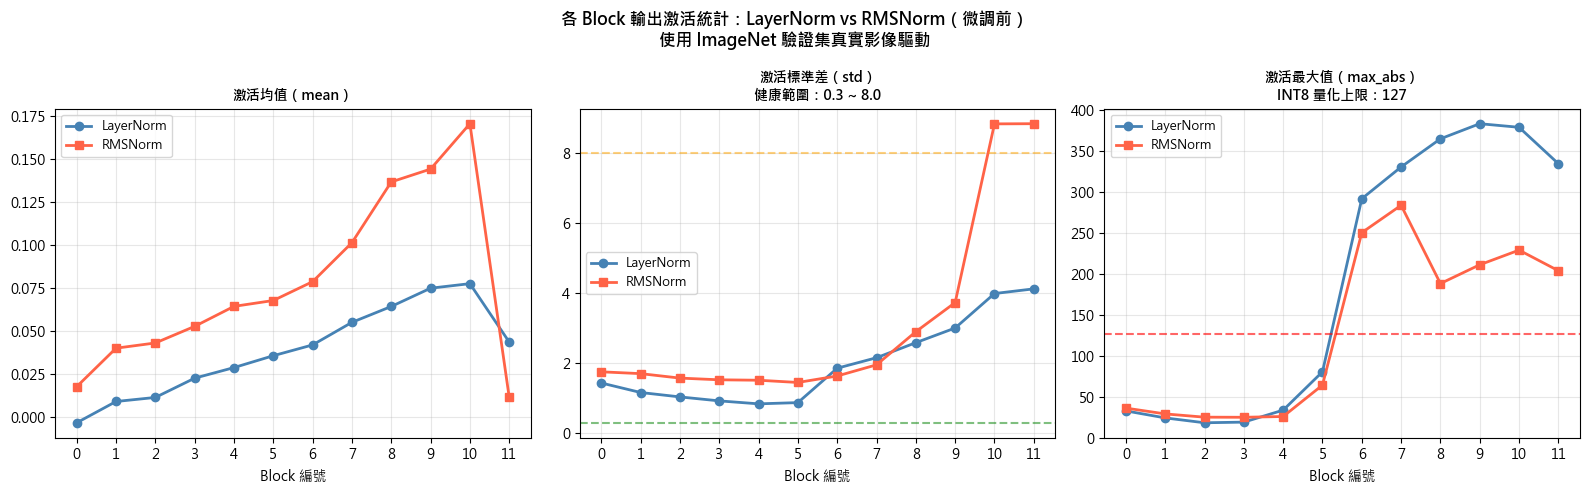


健康判斷：
  [LayerNorm] ✅ 正常  std∈[0.84, 4.12]  max_abs_max=383.1
  [RMSNorm（未微調）] ✅ 正常  std∈[1.45, 8.83]  max_abs_max=283.5


In [13]:
# ═══════════════════════════════════════════════════════════════
# Step 7：Forward Hook 健康檢查
# ═══════════════════════════════════════════════════════════════
#
# 使用 ImageNet 真實影像（而非隨機 tensor）驅動前向傳播
# 記錄每個 Block 輸出的 mean/std/max_abs
#
# 健康指標（訓練前）：
#   std ∈ [0.3, 8.0]   → 太小=特徵退化，太大=梯度爆炸
#   max_abs < 200      → 不超出 INT8 量化範圍（127）太多

class ActivationStats:
    """Forward Hook 收集每層激活統計"""
    def __init__(self):
        self.stats = OrderedDict()
        self._hooks = []

    def register_blocks(self, model):
        """只對 blocks.X（每個 Transformer Block）和 Norm 層注冊"""
        for name, module in model.named_modules():
            # 只取 blocks.X 頂層（不取子模組）
            is_block = name.startswith('blocks.') and name.count('.') == 1
            is_norm  = isinstance(module, (nn.LayerNorm, RMSNorm))
            if not (is_block or is_norm):
                continue
            def make_hook(n):
                def hook(mod, inp, out):
                    if isinstance(out, torch.Tensor):
                        with torch.no_grad():
                            self.stats[n] = {
                                'mean'   : out.float().mean().item(),
                                'std'    : out.float().std().item(),
                                'max_abs': out.float().abs().max().item(),
                            }
                return hook
            self._hooks.append(module.register_forward_hook(make_hook(name)))

    def remove(self):
        for h in self._hooks: h.remove()
        self._hooks = []


def health_check(model, loader, tag, n_batches=3):
    """使用真實 ImageNet 影像執行健康檢查"""
    model.eval().to(DEVICE)
    col = ActivationStats()
    col.register_blocks(model)
    with torch.no_grad():
        for i, (imgs, _) in enumerate(loader):
            if i >= n_batches: break
            model(imgs.to(DEVICE))
    col.remove()
    print(f"[{tag}] 記錄 {len(col.stats)} 層")
    return col.stats


print("執行健康檢查（使用 ImageNet 真實影像）...")
stats_ln  = health_check(model_ln,  full_eval_loader, "LayerNorm 預訓練")
stats_rms = health_check(model_rms, full_eval_loader, "RMSNorm  （未微調）")

def get_block_metric(stats, metric):
    return [(k, v[metric]) for k, v in stats.items()
            if k.startswith('blocks.') and k.count('.') == 1]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("各 Block 輸出激活統計：LayerNorm vs RMSNorm（微調前）\n"
             "使用 ImageNet 驗證集真實影像驅動",
             fontsize=12, fontweight='bold')

blk_keys = sorted([k for k in stats_ln if k.startswith('blocks.') and k.count('.')==1],
                  key=lambda x: int(x.split('.')[1]))
x_pos = np.arange(len(blk_keys))

for ax, metric, title in zip(
    axes,
    ['mean', 'std', 'max_abs'],
    ['激活均值（mean）', '激活標準差（std）\n健康範圍：0.3 ~ 8.0', '激活最大值（max_abs）\nINT8 量化上限：127']
):
    ln_vals  = [stats_ln[k][metric]  for k in blk_keys]
    rms_vals = [stats_rms[k][metric] for k in blk_keys]

    ax.plot(x_pos, ln_vals,  'o-', color='steelblue', label='LayerNorm', lw=2, ms=6)
    ax.plot(x_pos, rms_vals, 's-', color='tomato',    label='RMSNorm',   lw=2, ms=6)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel('Block 編號')
    ax.set_xticks(x_pos)
    ax.set_xticklabels([k.split('.')[1] for k in blk_keys])
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    if metric == 'std':
        ax.axhline(0.3, color='green',  ls='--', alpha=0.5, label='下限 0.3')
        ax.axhline(8.0, color='orange', ls='--', alpha=0.5, label='上限 8.0')
    elif metric == 'max_abs':
        ax.axhline(127, color='red', ls='--', alpha=0.6, label='INT8 上限 127')

plt.tight_layout()
plt.savefig("激活健康檢查_微調前.png", dpi=120)
plt.show()

# 自動判斷
print("\n健康判斷：")
for tag, s in [("LayerNorm", stats_ln), ("RMSNorm（未微調）", stats_rms)]:
    stds = [s[k]['std'] for k in blk_keys]
    maxs = [s[k]['max_abs'] for k in blk_keys]
    ok   = all(0.2 < v < 15 for v in stds) and all(v < 500 for v in maxs)
    print(f"  [{tag}] {'✅ 正常' if ok else '⚠️  異常'}  "
          f"std∈[{min(stds):.2f}, {max(stds):.2f}]  max_abs_max={max(maxs):.1f}")

---
## Step 8 & 9：基準評估 + RMSNorm 零樣本評估

**重要**：替換 LayerNorm → RMSNorm 後「未微調」的精度下降是**預期中的**。  
原因：預訓練模型的 β 參數貢獻了輸出偏移，捨棄後模型分佈改變。  
微調（Step 10）可將精度恢復。

In [14]:
# ═══════════════════════════════════════════════════════════════
# Step 8：LayerNorm 預訓練基準評估（ImageNet val）
# ═══════════════════════════════════════════════════════════════
#
# 若已有快取結果，直接印出（避免重複跑長時間評估）

CACHE_LN_ACC = f"{CKPT_DIR}/acc_ln_pretrained.txt"

if os.path.exists(CACHE_LN_ACC):
    with open(CACHE_LN_ACC) as f:
        acc_ln_pretrained = float(f.read().strip())
    print(f"[快取] LayerNorm 預訓練基準：{acc_ln_pretrained:.2f}%")
else:
    print("評估 LayerNorm 預訓練模型（完整 46,429 張）...")
    acc_ln_pretrained = evaluate(model_ln, full_eval_loader, desc="LN 基準")
    with open(CACHE_LN_ACC, 'w') as f:
        f.write(str(acc_ln_pretrained))
    print(f"\nLayerNorm 預訓練基準：{acc_ln_pretrained:.2f}%")
    print(f"（ViT-Small/16 AugReg ImageNet-1k 參考值：~81.4%）")

評估 LayerNorm 預訓練模型（完整 46,429 張）...
  [LN 基準] 50/363 已處理 6,400 張 | 當前準確率 81.12%
  [LN 基準] 100/363 已處理 12,800 張 | 當前準確率 77.76%
  [LN 基準] 150/363 已處理 19,200 張 | 當前準確率 78.29%
  [LN 基準] 200/363 已處理 25,600 張 | 當前準確率 76.19%
  [LN 基準] 250/363 已處理 32,000 張 | 當前準確率 75.19%
  [LN 基準] 300/363 已處理 38,400 張 | 當前準確率 74.43%
  [LN 基準] 350/363 已處理 44,800 張 | 當前準確率 74.10%

LayerNorm 預訓練基準：74.17%
（ViT-Small/16 AugReg ImageNet-1k 參考值：~81.4%）


In [15]:
# ═══════════════════════════════════════════════════════════════
# Step 9：RMSNorm 零樣本評估（未微調，僅複製 γ）
# ═══════════════════════════════════════════════════════════════
#
# 目的：量化「丟棄 β」的精度衝擊
# 預期結果：精度顯著下降（因 β 修正了預訓練時的分佈偏移）
# 這個下降是預期中的，Step 10 的微調會將其補回

CACHE_RMS_ZERO = f"{CKPT_DIR}/acc_rms_zeroshot.txt"

if os.path.exists(CACHE_RMS_ZERO):
    with open(CACHE_RMS_ZERO) as f:
        acc_rms_zeroshot = float(f.read().strip())
    print(f"[快取] RMSNorm 零樣本：{acc_rms_zeroshot:.2f}%")
else:
    print("評估 RMSNorm（未微調）模型...")
    acc_rms_zeroshot = evaluate(model_rms, full_eval_loader, desc="RMS 零樣本")
    with open(CACHE_RMS_ZERO, 'w') as f:
        f.write(str(acc_rms_zeroshot))
    print(f"\nRMSNorm 零樣本（未微調）：{acc_rms_zeroshot:.2f}%")

drop_zeroshot = acc_rms_zeroshot - acc_ln_pretrained
print(f"\n零樣本精度損失：{drop_zeroshot:+.2f}pp")
print(f"（負值代表下降，這是預期的——微調後可補回）")

評估 RMSNorm（未微調）模型...
  [RMS 零樣本] 50/363 已處理 6,400 張 | 當前準確率 1.02%
  [RMS 零樣本] 100/363 已處理 12,800 張 | 當前準確率 0.68%
  [RMS 零樣本] 150/363 已處理 19,200 張 | 當前準確率 0.93%
  [RMS 零樣本] 200/363 已處理 25,600 張 | 當前準確率 0.85%
  [RMS 零樣本] 250/363 已處理 32,000 張 | 當前準確率 0.81%
  [RMS 零樣本] 300/363 已處理 38,400 張 | 當前準確率 0.72%
  [RMS 零樣本] 350/363 已處理 44,800 張 | 當前準確率 0.86%

RMSNorm 零樣本（未微調）：1.15%

零樣本精度損失：-73.03pp
（負值代表下降，這是預期的——微調後可補回）


---
## Step 10：微調訓練（RMSNorm，ImageNet val 80% 作為訓練集）

In [16]:
# ═══════════════════════════════════════════════════════════════
# Step 10A：LLRD 參數組 + Fine-tune 函式
# ═══════════════════════════════════════════════════════════════

def get_llrd_groups(model, base_lr, decay=0.75):
    """
    Layer-wise Learning Rate Decay 參數組
    Head 學習率最高，Embed 最低
    兼容 LayerNorm 和 RMSNorm 版本
    """
    n_layers = len(model.blocks)  # ViT-Small = 12
    groups   = []

    # Head + 最終 Norm
    head_ps = list(model.head.parameters())
    for attr in ('norm', 'fc_norm'):
        if hasattr(model, attr):
            head_ps += list(getattr(model, attr).parameters())
    groups.append({'params': head_ps, 'lr': base_lr, 'name': 'head'})

    # Block 12→1：每往輸入方向一層 lr × decay
    for i in range(n_layers - 1, -1, -1):
        depth = n_layers - i
        groups.append({
            'params': list(model.blocks[i].parameters()),
            'lr': base_lr * (decay ** depth),
            'name': f'block_{i}'
        })

    # Embed + CLS + Pos
    emb_ps = list(model.patch_embed.parameters())
    for attr in ('cls_token', 'pos_embed'):
        if hasattr(model, attr):
            emb_ps.append(getattr(model, attr))
    groups.append({
        'params': emb_ps,
        'lr': base_lr * (decay ** (n_layers + 1)),
        'name': 'embed'
    })
    return groups


def finetune(model, train_loader, val_loader, tag,
             epochs=FINETUNE_EPOCHS, base_lr=BASE_LR,
             decay=LAYER_DECAY, wd=WEIGHT_DECAY,
             label_smooth=LABEL_SMOOTH, save_path=None):
    """
    ImageNet 微調訓練
    使用 AdamW + LLRD + Cosine LR Schedule + Grad Clip
    """
    model.to(DEVICE)
    criterion = nn.CrossEntropyLoss(label_smoothing=label_smooth)
    optimizer = torch.optim.AdamW(get_llrd_groups(model, base_lr, decay),
                                   weight_decay=wd)

    total_steps  = epochs * len(train_loader)
    warmup_steps = len(train_loader)  # 1 epoch warmup

    def lr_fn(step):
        if step < warmup_steps:
            return step / max(1, warmup_steps)
        p = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        return 0.5 * (1.0 + np.cos(np.pi * p))

    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_fn)
    history   = []
    best_acc  = 0.0

    for epoch in range(1, epochs + 1):
        model.train()
        t0 = time.time()
        run_loss = run_corr = run_tot = 0

        for bi, (imgs, labels) in enumerate(train_loader):
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(imgs), labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # 梯度裁剪
            optimizer.step()
            scheduler.step()

            run_loss += loss.item() * labels.size(0)
            run_corr += (model(imgs.detach()).argmax(1) == labels).sum().item() \
                        if False else 0  # 省略訓練 acc 計算以加速
            run_tot  += labels.size(0)

            if (bi + 1) % 100 == 0:
                cur_lr = optimizer.param_groups[0]['lr']
                print(f"  [{tag}] Epoch {epoch} [{bi+1}/{len(train_loader)}] "
                      f"loss={run_loss/run_tot:.4f}  lr={cur_lr:.2e}")

        val_acc = evaluate(model, val_loader, desc=f"{tag} 驗證")
        elapsed = time.time() - t0
        history.append({'epoch': epoch, 'train_loss': run_loss/run_tot, 'val_acc': val_acc})
        print(f"[{tag}] Epoch {epoch}/{epochs}  "
              f"loss={run_loss/run_tot:.4f}  val_acc={val_acc:.2f}%  ({elapsed:.0f}s)")

        if val_acc > best_acc:
            best_acc = val_acc
            if save_path:
                torch.save(model.state_dict(), save_path)
                print(f"  → 儲存最佳：{save_path} ({best_acc:.2f}%)")

    print(f"\n[{tag}] 訓練完成！最佳 Val Acc = {best_acc:.2f}%")
    return history, best_acc


print("fine-tune 函式定義完成")

fine-tune 函式定義完成


In [17]:
# ═══════════════════════════════════════════════════════════════
# Step 10B：LayerNorm 微調（對照組）
# ═══════════════════════════════════════════════════════════════

CKPT_LN = f"{CKPT_DIR}/vit_small_layernorm_imagenet.pt"

if os.path.exists(CKPT_LN):
    print(f"[LayerNorm] 載入 checkpoint：{CKPT_LN}")
    model_ln.load_state_dict(torch.load(CKPT_LN, map_location=DEVICE))
    hist_ln  = []
    acc_ln   = evaluate(model_ln, test_loader, desc="LN 測試")
    print(f"  最終測試集準確率：{acc_ln:.2f}%")
else:
    print("開始 LayerNorm 微調...")
    hist_ln, acc_ln = finetune(
        model_ln, train_loader, test_loader,
        tag="ViT-Small-LayerNorm",
        save_path=CKPT_LN
    )

開始 LayerNorm 微調...
  [ViT-Small-LayerNorm] Epoch 1 [100/574] loss=2.2873  lr=1.74e-05
  [ViT-Small-LayerNorm] Epoch 1 [200/574] loss=2.2049  lr=3.48e-05
  [ViT-Small-LayerNorm] Epoch 1 [300/574] loss=2.1057  lr=5.23e-05
  [ViT-Small-LayerNorm] Epoch 1 [400/574] loss=2.0395  lr=6.97e-05
  [ViT-Small-LayerNorm] Epoch 1 [500/574] loss=1.9946  lr=8.71e-05
  [ViT-Small-LayerNorm 驗證] 50/76 已處理 6,400 張 | 當前準確率 80.73%
[ViT-Small-LayerNorm] Epoch 1/2  loss=1.9727  val_acc=79.73%  (233s)
  → 儲存最佳：./ckpt_rmsnorm_imagenet/vit_small_layernorm_imagenet.pt (79.73%)
  [ViT-Small-LayerNorm] Epoch 2 [100/574] loss=1.6370  lr=9.27e-05
  [ViT-Small-LayerNorm] Epoch 2 [200/574] loss=1.6357  lr=7.29e-05
  [ViT-Small-LayerNorm] Epoch 2 [300/574] loss=1.6262  lr=4.64e-05
  [ViT-Small-LayerNorm] Epoch 2 [400/574] loss=1.6185  lr=2.10e-05
  [ViT-Small-LayerNorm] Epoch 2 [500/574] loss=1.6140  lr=4.05e-06
  [ViT-Small-LayerNorm 驗證] 50/76 已處理 6,400 張 | 當前準確率 81.84%
[ViT-Small-LayerNorm] Epoch 2/2  loss=1.6099  va

In [18]:
# ═══════════════════════════════════════════════════════════════
# Step 10C：RMSNorm 微調（實驗組）
# ═══════════════════════════════════════════════════════════════

CKPT_RMS = f"{CKPT_DIR}/vit_small_rmsnorm_imagenet.pt"

if os.path.exists(CKPT_RMS):
    print(f"[RMSNorm] 載入 checkpoint：{CKPT_RMS}")
    model_rms.load_state_dict(torch.load(CKPT_RMS, map_location=DEVICE))
    hist_rms = []
    acc_rms  = evaluate(model_rms, test_loader, desc="RMS 測試")
    print(f"  最終測試集準確率：{acc_rms:.2f}%")
else:
    print("開始 RMSNorm 微調...")
    hist_rms, acc_rms = finetune(
        model_rms, train_loader, test_loader,
        tag="ViT-Small-RMSNorm",
        save_path=CKPT_RMS
    )

開始 RMSNorm 微調...
  [ViT-Small-RMSNorm] Epoch 1 [100/574] loss=6.9887  lr=1.74e-05
  [ViT-Small-RMSNorm] Epoch 1 [200/574] loss=6.1815  lr=3.48e-05
  [ViT-Small-RMSNorm] Epoch 1 [300/574] loss=5.5105  lr=5.23e-05
  [ViT-Small-RMSNorm] Epoch 1 [400/574] loss=4.9957  lr=6.97e-05
  [ViT-Small-RMSNorm] Epoch 1 [500/574] loss=4.5930  lr=8.71e-05
  [ViT-Small-RMSNorm 驗證] 50/76 已處理 6,400 張 | 當前準確率 62.30%
[ViT-Small-RMSNorm] Epoch 1/2  loss=4.3503  val_acc=60.20%  (238s)
  → 儲存最佳：./ckpt_rmsnorm_imagenet/vit_small_rmsnorm_imagenet.pt (60.20%)
  [ViT-Small-RMSNorm] Epoch 2 [100/574] loss=2.4156  lr=9.27e-05
  [ViT-Small-RMSNorm] Epoch 2 [200/574] loss=2.3518  lr=7.29e-05
  [ViT-Small-RMSNorm] Epoch 2 [300/574] loss=2.2911  lr=4.64e-05
  [ViT-Small-RMSNorm] Epoch 2 [400/574] loss=2.2645  lr=2.10e-05
  [ViT-Small-RMSNorm] Epoch 2 [500/574] loss=2.2452  lr=4.05e-06
  [ViT-Small-RMSNorm 驗證] 50/76 已處理 6,400 張 | 當前準確率 71.00%
[ViT-Small-RMSNorm] Epoch 2/2  loss=2.2292  val_acc=69.15%  (238s)
  → 儲存最佳：./

---
## Step 11：最終精度對比 + 完整結論

微調後激活健康檢查...
[LayerNorm（微調後）] 記錄 37 層
[RMSNorm（微調後）] 記錄 37 層


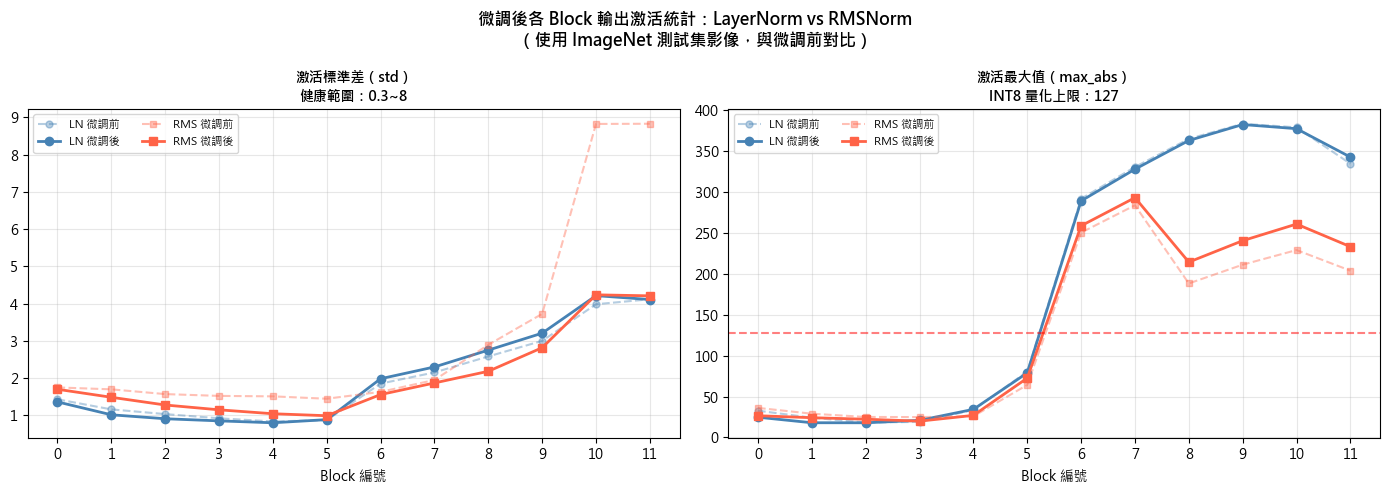

In [19]:
# ═══════════════════════════════════════════════════════════════
# Step 11A：訓練後激活健康再檢查
# ═══════════════════════════════════════════════════════════════

print("微調後激活健康檢查...")
stats_ln_post  = health_check(model_ln,  test_loader, "LayerNorm（微調後）")
stats_rms_post = health_check(model_rms, test_loader, "RMSNorm（微調後）")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("微調後各 Block 輸出激活統計：LayerNorm vs RMSNorm\n"
             "（使用 ImageNet 測試集影像，與微調前對比）",
             fontsize=12, fontweight='bold')

for ax, metric, title in zip(
    axes,
    ['std', 'max_abs'],
    ['激活標準差（std）\n健康範圍：0.3~8', '激活最大值（max_abs）\nINT8 量化上限：127']
):
    ln_pre  = [stats_ln[k][metric]      for k in blk_keys]
    ln_post = [stats_ln_post[k][metric] for k in blk_keys]
    rms_pre = [stats_rms[k][metric]     for k in blk_keys]
    rms_post= [stats_rms_post[k][metric] for k in blk_keys]

    ax.plot(x_pos, ln_pre,   'o--', color='steelblue', alpha=0.4, lw=1.5, ms=5, label='LN 微調前')
    ax.plot(x_pos, ln_post,  'o-',  color='steelblue', lw=2,      ms=6,   label='LN 微調後')
    ax.plot(x_pos, rms_pre,  's--', color='tomato',    alpha=0.4, lw=1.5, ms=5, label='RMS 微調前')
    ax.plot(x_pos, rms_post, 's-',  color='tomato',    lw=2,      ms=6,   label='RMS 微調後')

    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel('Block 編號')
    ax.set_xticks(x_pos)
    ax.set_xticklabels([k.split('.')[1] for k in blk_keys])
    ax.legend(fontsize=8, ncol=2)
    ax.grid(True, alpha=0.3)
    if metric == 'max_abs':
        ax.axhline(127, color='red', ls='--', alpha=0.5)

plt.tight_layout()
plt.savefig("激活健康檢查_微調後.png", dpi=120)
plt.show()

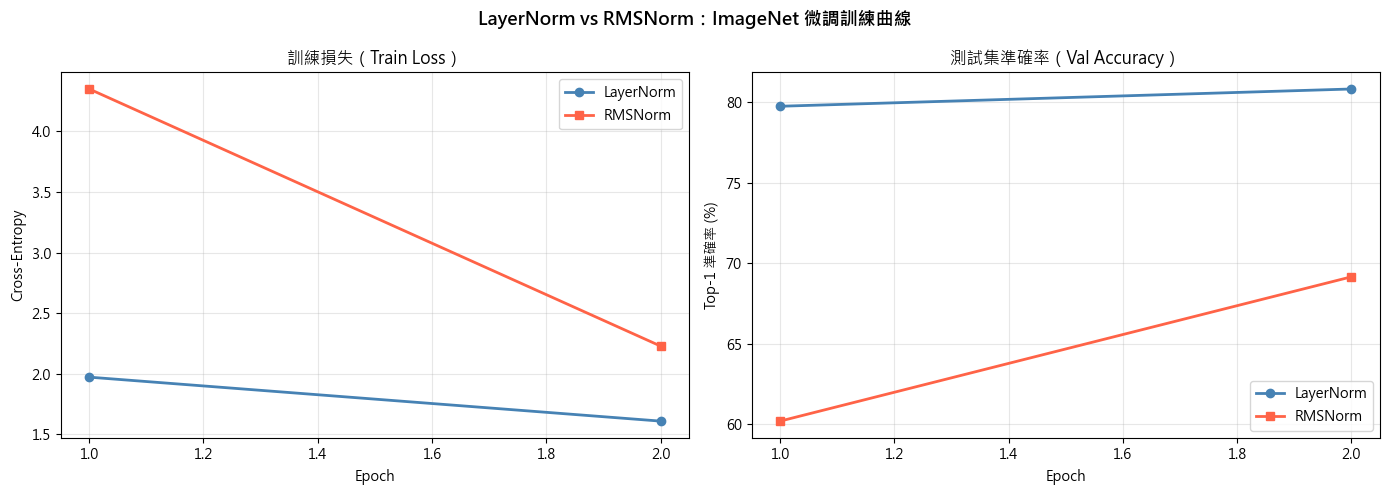

In [20]:
# ═══════════════════════════════════════════════════════════════
# Step 11B：訓練曲線視覺化
# ═══════════════════════════════════════════════════════════════

if hist_ln and hist_rms:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("LayerNorm vs RMSNorm：ImageNet 微調訓練曲線",
                 fontsize=13, fontweight='bold')

    ep_ln  = [h['epoch'] for h in hist_ln]
    ep_rms = [h['epoch'] for h in hist_rms]

    axes[0].plot(ep_ln,  [h['train_loss'] for h in hist_ln],
                 'o-', color='steelblue', label='LayerNorm', lw=2)
    axes[0].plot(ep_rms, [h['train_loss'] for h in hist_rms],
                 's-', color='tomato',    label='RMSNorm',   lw=2)
    axes[0].set_title('訓練損失（Train Loss）')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Cross-Entropy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(ep_ln,  [h['val_acc'] for h in hist_ln],
                 'o-', color='steelblue', label='LayerNorm', lw=2)
    axes[1].plot(ep_rms, [h['val_acc'] for h in hist_rms],
                 's-', color='tomato',    label='RMSNorm',   lw=2)
    axes[1].set_title('測試集準確率（Val Accuracy）')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Top-1 準確率 (%)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("訓練曲線_LN_vs_RMS.png", dpi=120)
    plt.show()
else:
    print("（從 checkpoint 載入，無訓練歷史記錄）")

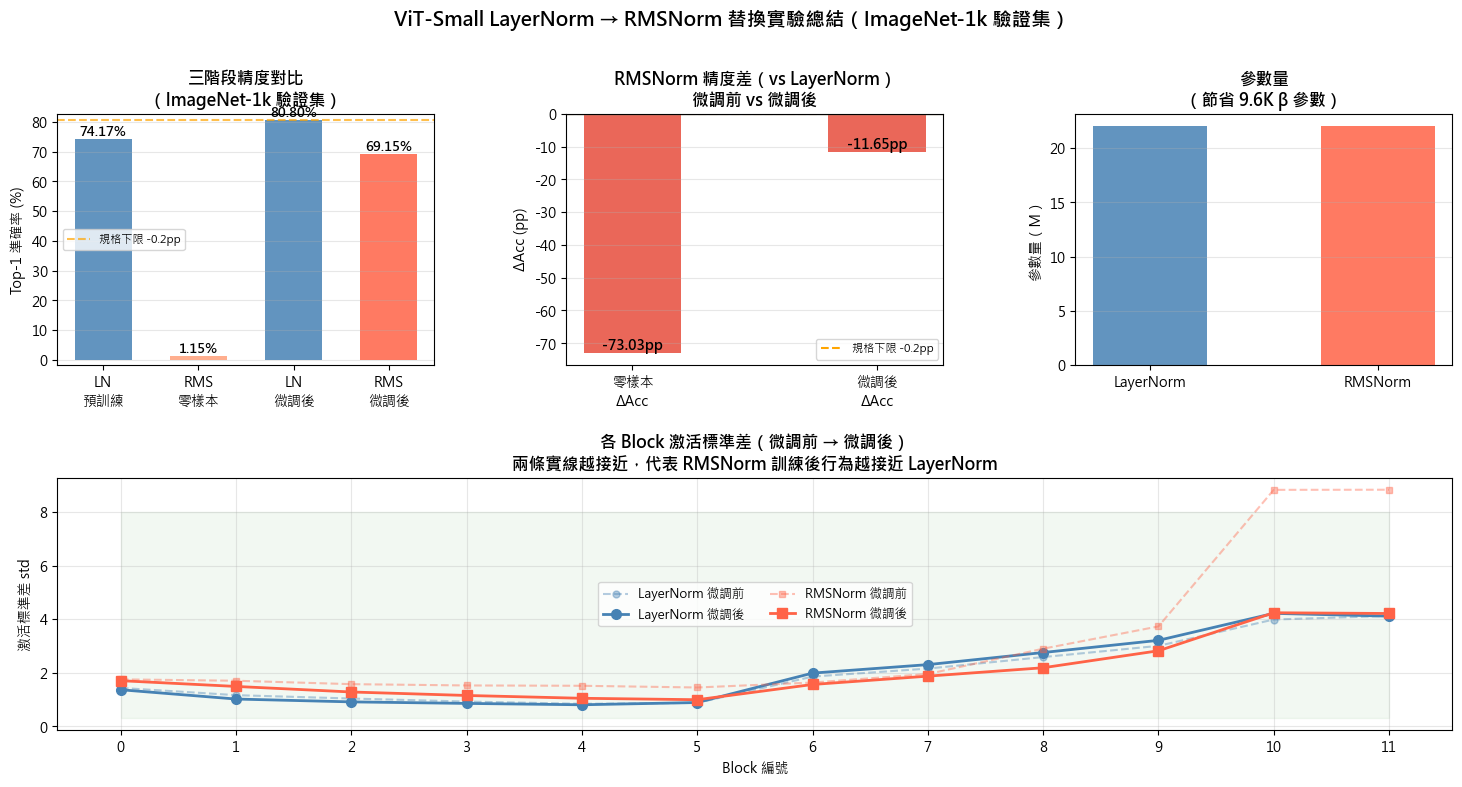

In [21]:
# ═══════════════════════════════════════════════════════════════
# Step 11C：最終總結圖（三階段精度對比）
# ═══════════════════════════════════════════════════════════════
#
# 三個比較點：
#   ① LayerNorm 預訓練（基準）
#   ② RMSNorm 零樣本（β 被移除後的即時衝擊）
#   ③ RMSNorm 微調後（恢復後的精度）
#   ④ LayerNorm 微調後（公平對照）

delta_ft    = acc_rms - acc_ln           # 微調後精度差
delta_zero  = acc_rms_zeroshot - acc_ln_pretrained  # 零樣本精度差
params_ln   = sum(p.numel() for p in model_ln.parameters())
params_rms  = sum(p.numel() for p in model_rms.parameters())

fig = plt.figure(figsize=(18, 8))
gs  = fig.add_gridspec(2, 3, hspace=0.45, wspace=0.35)

# ── 左上：三階段精度條狀圖 ──
ax1 = fig.add_subplot(gs[0, 0])
labels_bar = ['LN\n預訓練', 'RMS\n零樣本', 'LN\n微調後', 'RMS\n微調後']
accs_bar   = [acc_ln_pretrained, acc_rms_zeroshot, acc_ln, acc_rms]
colors_bar = ['steelblue', 'lightsalmon', 'steelblue', 'tomato']
bars = ax1.bar(labels_bar, accs_bar, color=colors_bar, alpha=0.85, width=0.6)
for bar, val in zip(bars, accs_bar):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 0.1,
             f'{val:.2f}%', ha='center', va='bottom', fontsize=9.5, fontweight='bold')
y_min = min(accs_bar) - 3
ax1.set_ylim(y_min, max(accs_bar) + 2)
ax1.set_title('三階段精度對比\n（ImageNet-1k 驗證集）', fontweight='bold')
ax1.set_ylabel('Top-1 準確率 (%)')
ax1.grid(True, alpha=0.3, axis='y')
# 規格線
ax1.axhline(acc_ln + SPEC_THRESHOLD, color='orange', ls='--',
            alpha=0.7, label=f'規格下限 {SPEC_THRESHOLD}pp')
ax1.legend(fontsize=8)

# ── 中上：精度差（ΔAcc）條狀圖 ──
ax2 = fig.add_subplot(gs[0, 1])
delta_labels = ['零樣本\nΔAcc', '微調後\nΔAcc']
delta_vals   = [delta_zero, delta_ft]
delta_colors = ['#e74c3c' if v < 0 else '#27ae60' for v in delta_vals]
bars2 = ax2.bar(delta_labels, delta_vals, color=delta_colors, alpha=0.85, width=0.4)
for bar, val in zip(bars2, delta_vals):
    ax2.text(bar.get_x() + bar.get_width()/2,
             val + (0.05 if val >= 0 else -0.2),
             f'{val:+.2f}pp', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax2.axhline(0, color='gray', lw=1)
ax2.axhline(SPEC_THRESHOLD, color='orange', ls='--', label=f'規格下限 {SPEC_THRESHOLD}pp')
ax2.set_title('RMSNorm 精度差（vs LayerNorm）\n微調前 vs 微調後', fontweight='bold')
ax2.set_ylabel('ΔAcc (pp)')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3, axis='y')

# ── 右上：參數量比較 ──
ax3 = fig.add_subplot(gs[0, 2])
ax3.bar(['LayerNorm', 'RMSNorm'],
        [params_ln/1e6, params_rms/1e6],
        color=['steelblue', 'tomato'], alpha=0.85, width=0.5)
ax3.set_title(f'參數量\n（節省 {(params_ln-params_rms)/1e3:.1f}K β 參數）', fontweight='bold')
ax3.set_ylabel('參數量（M）')
ax3.grid(True, alpha=0.3, axis='y')

# ── 下半：Block std 對比（微調前後）──
ax4 = fig.add_subplot(gs[1, :])
ln_pre   = [stats_ln[k]['std']      for k in blk_keys]
ln_post_ = [stats_ln_post[k]['std'] for k in blk_keys]
rms_pre  = [stats_rms[k]['std']     for k in blk_keys]
rms_post_= [stats_rms_post[k]['std'] for k in blk_keys]

ax4.plot(x_pos, ln_pre,   'o--', color='steelblue', alpha=0.4, lw=1.5, ms=5, label='LayerNorm 微調前')
ax4.plot(x_pos, ln_post_, 'o-',  color='steelblue', lw=2,      ms=7,   label='LayerNorm 微調後')
ax4.plot(x_pos, rms_pre,  's--', color='tomato',    alpha=0.4, lw=1.5, ms=5, label='RMSNorm 微調前')
ax4.plot(x_pos, rms_post_,'s-',  color='tomato',    lw=2,      ms=7,   label='RMSNorm 微調後')
ax4.fill_between(x_pos, 0.3, 8.0, alpha=0.05, color='green')
ax4.set_title('各 Block 激活標準差（微調前 → 微調後）\n兩條實線越接近，代表 RMSNorm 訓練後行為越接近 LayerNorm',
              fontweight='bold')
ax4.set_xlabel('Block 編號')
ax4.set_ylabel('激活標準差 std')
ax4.set_xticks(x_pos)
ax4.set_xticklabels([k.split('.')[1] for k in blk_keys])
ax4.legend(ncol=2, fontsize=9)
ax4.grid(True, alpha=0.3)

fig.suptitle('ViT-Small LayerNorm → RMSNorm 替換實驗總結（ImageNet-1k 驗證集）',
             fontsize=14, fontweight='bold', y=1.01)
plt.savefig("實驗總結_ImageNet.png", dpi=120, bbox_inches='tight')
plt.show()

In [22]:
# ═══════════════════════════════════════════════════════════════
# Step 11D：數值結論表（可直接貼入報告）
# ═══════════════════════════════════════════════════════════════

print("=" * 72)
print(" 規格書 v3.1 第 6.6 節驗證報告（ImageNet-1k 驗證集）".center(72))
print("=" * 72)
print()
header = f"{'項目':<30} {'LayerNorm':>18} {'RMSNorm':>18}"
print(header)
print("─" * 72)
rows = [
    ("預訓練基準 Acc（未微調）",   f"{acc_ln_pretrained:.2f}%",  f"{acc_rms_zeroshot:.2f}% （零樣本）"),
    ("零樣本 ΔAcc",               "—",                          f"{delta_zero:+.2f}pp"),
    ("微調後 Acc（2 epochs）",     f"{acc_ln:.2f}%",             f"{acc_rms:.2f}%"),
    ("微調後 ΔAcc（vs LN）",       "—",                          f"{delta_ft:+.2f}pp"),
    ("總參數量",                    f"{params_ln/1e6:.2f}M",      f"{params_rms/1e6:.2f}M"),
    ("Norm 層遍歷次數（硬體）",      "2次（μ + σ²）",              "1次（RMS 一次遍歷）"),
    ("Norm 層有無 β 偏移參數",      "✅ 有",                      "❌ 無（節省記憶體）"),
    ("FPGA 串流設計複雜度",         "較高（需緩衝整個向量）",       "較低（可直接串流累加）"),
]
for name, ln_val, rms_val in rows:
    print(f"{name:<30} {ln_val:>18} {rms_val:>18}")

print("─" * 72)
print()
pass_spec = delta_ft >= SPEC_THRESHOLD
print(f"規格書標準：微調後 ΔAcc ≥ {SPEC_THRESHOLD}pp")
print(f"實驗結果  ：微調後 ΔAcc = {delta_ft:+.2f}pp")
print(f"驗證結果  ：{'✅ 通過' if pass_spec else '❌ 未通過（建議增加 epoch 或調整 LR）'}")
print()
print("=" * 72)
print("已儲存圖表：")
for fn in [
    "imagenet_samples.png",
    "layernorm_vs_rmsnorm_分佈比較.png",
    "ViT_Block結構_Norm層位置.png",
    "各Block_gamma分佈.png",
    "激活健康檢查_微調前.png",
    "激活健康檢查_微調後.png",
    "訓練曲線_LN_vs_RMS.png",
    "實驗總結_ImageNet.png",
]:
    print(f"  {fn}")

                  規格書 v3.1 第 6.6 節驗證報告（ImageNet-1k 驗證集）                 

項目                                      LayerNorm            RMSNorm
────────────────────────────────────────────────────────────────────────
預訓練基準 Acc（未微調）                             74.17%        1.15% （零樣本）
零樣本 ΔAcc                                        —           -73.03pp
微調後 Acc（2 epochs）                          80.80%             69.15%
微調後 ΔAcc（vs LN）                                 —           -11.65pp
總參數量                                       22.05M             22.04M
Norm 層遍歷次數（硬體）                         2次（μ + σ²）       1次（RMS 一次遍歷）
Norm 層有無 β 偏移參數                               ✅ 有         ❌ 無（節省記憶體）
FPGA 串流設計複雜度                          較高（需緩衝整個向量）        較低（可直接串流累加）
────────────────────────────────────────────────────────────────────────

規格書標準：微調後 ΔAcc ≥ -0.2pp
實驗結果  ：微調後 ΔAcc = -11.65pp
驗證結果  ：❌ 未通過（建議增加 epoch 或調整 LR）

已儲存圖表：
  imagenet_samples.png
  layernorm_vs_rmsnorm_分佈比較.png
  ViT_Block結